### Import bibliotek i podstawowa konfiguracja

In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

ADOPTION_SPEED_LABELS = {
    0: '0',
    1: '1–7',
    2: '8–30',
    3: '31–90',
    4: '>100',
}
CLASS_ORDER = sorted(ADOPTION_SPEED_LABELS.keys())
CLASS_NAMES = [ADOPTION_SPEED_LABELS[c] for c in CLASS_ORDER]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Wczytanie i przygotowanie danych

In [ ]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = Path('../models')
INPUT_PATH = f'{PROCESSED_DIR}/train_clean_anomaly.csv'

df = pd.read_csv(INPUT_PATH)

# Nie dodajemy do modelu rekordów-anomalii
if 'is_anomaly' in df.columns:
    df = df.drop(columns=['is_anomaly'])

y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])

# Kodowanie kolumn tekstowych
text_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
for col in text_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

feature_names = X.columns.tolist()

print('Podgląd danych:')
display(df.head())


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'\nX_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')


# Rozkład klas
class_distribution = pd.DataFrame({
    'y (całość) %': (y.value_counts(normalize=True).sort_index() * 100).round(2),
    'y_train %': (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    'y_test %': (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})
class_distribution.index.name = 'AdoptionSpeed'

print('Rozkład klas AdoptionSpeed (%):')
display(class_distribution)

Podgląd danych:


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Health,Quantity,Fee,RescuerID,VideoAmt,PetID,PhotoAmt,AdoptionSpeed,HasName,DescLength
0,2,3,299,0,1,1,7,0,1,1,...,1,1,100,8480853f516546f6cf33aa88cd76c379,0,86e1089a3,1.0,2,1,359
1,2,1,265,0,1,1,2,0,2,2,...,1,1,0,3082c7125d8fb66f7dd4bff4192c8b14,0,6296e909a,2.0,0,1,118
2,1,1,307,0,1,2,7,0,2,2,...,1,1,0,fa90fa5b1ee11c86938398b60abc32cb,0,3422e4906,7.0,3,1,393
3,1,4,307,0,2,1,2,0,2,1,...,1,1,150,9238e4f44c71a75282e62f7136c6b240,0,5842f1ff5,8.0,2,1,146
4,1,1,307,0,1,1,0,0,2,1,...,1,1,0,95481e953f8aed9ec3d16fc4509537e8,0,850a43f90,3.0,2,1,390



X_train: (11994, 22), y_train: (11994,)
X_test:  (2999, 22), y_test:  (2999,)
Rozkład klas AdoptionSpeed (%):


,y (całość) %,y_train %,y_test %
AdoptionSpeed,,,
0,2.73,2.73,2.73
1,20.61,20.61,20.61
2,26.93,26.93,26.91
3,21.74,21.74,21.74
4,27.99,27.99,28.01


### Random Forest

Classification report
              precision    recall  f1-score   support

           0       0.80      0.05      0.09        82
         1–7       0.36      0.34      0.35       618
        8–30       0.36      0.40      0.38       807
       31–90       0.44      0.26      0.33       652
        >100       0.51      0.68      0.58       840

    accuracy                           0.43      2999
   macro avg       0.49      0.35      0.35      2999
weighted avg       0.43      0.43      0.41      2999

Accuracy: 0.4281


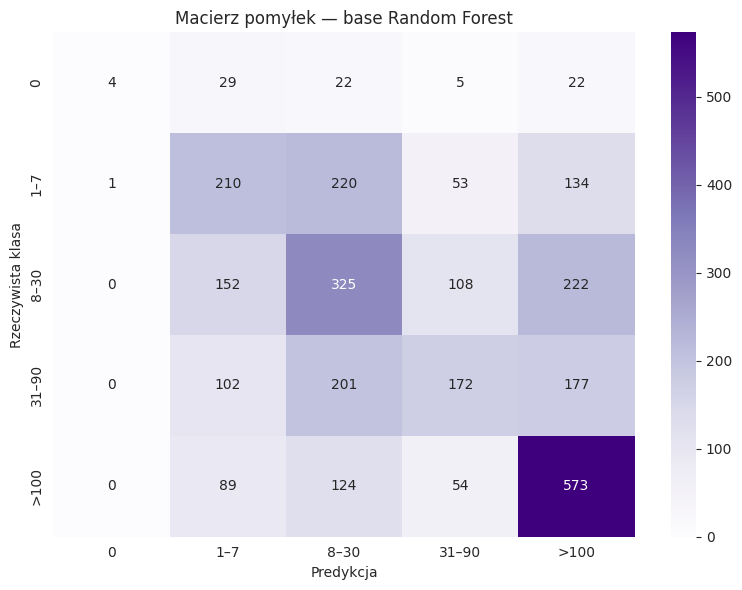

In [6]:
rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average='macro')

print('Classification report')
print(classification_report(
    y_test,
    y_pred_base,
    target_names=CLASS_NAMES,
))
print(f'Accuracy: {acc_base:.4f}')

cm_base = confusion_matrix(y_test, y_pred_base, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Macierz pomyłek — base Random Forest')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Kalibracja

### Zapis modelu